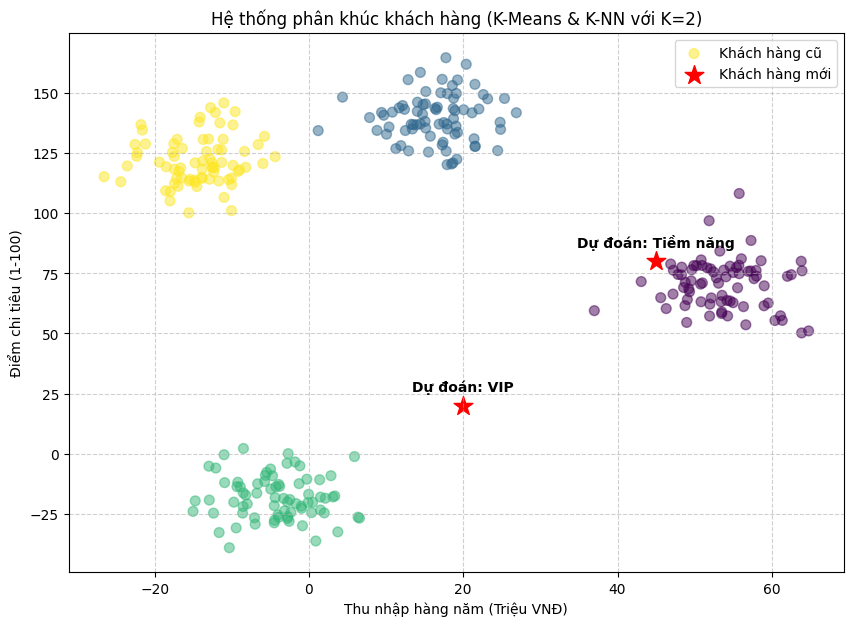

--- KẾT QUẢ DỰ ĐOÁN ---
Khách hàng mới 1 (Thu nhập: 45tr, Chi tiêu: 80đ): Xếp vào nhóm Tiềm năng
Khách hàng mới 2 (Thu nhập: 20tr, Chi tiêu: 20đ): Xếp vào nhóm VIP


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# ==========================================
# Bước 1: Tạo dữ liệu khách hàng giả lập
# ==========================================
# Giả lập 300 khách hàng với: [Thu nhập (triệu/tháng), Điểm chi tiêu (1-100)]
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Điều chỉnh lại tỉ lệ dữ liệu cho giống thực tế
X[:, 0] = X[:, 0] * 5 + 30  # Thu nhập từ 10 - 60 triệu
X[:, 1] = X[:, 1] * 10 + 50 # Điểm chi tiêu từ 1 - 100

# ==========================================
# Bước 2: Sử dụng K-Means để phân nhóm khách hàng
# ==========================================
# Giả sử chúng ta muốn chia khách hàng thành 4 nhóm
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto')
cluster_labels = kmeans.fit_transform(X)
labels = kmeans.labels_

# Tên các nhóm khách hàng dựa trên phân cụm
group_names = {0: "Tiềm năng", 1: "Tiết kiệm", 2: "VIP", 3: "Trung thành"}

# ==========================================
# Bước 3: Sử dụng K-NN để dự đoán khách hàng mới
# ==========================================
# Tìm K tốt nhất cho K-NN
param_grid = {'n_neighbors': np.arange(1, 11)}
knn_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_search.fit(X, labels)
best_k = knn_search.best_params_['n_neighbors']

# Huấn luyện mô hình K-NN cuối cùng
knn_classifier = KNeighborsClassifier(n_neighbors=best_k)
knn_classifier.fit(X, labels)

# Giả sử có 2 khách hàng mới bước vào cửa hàng:
# Khách A: Thu nhập 45tr, Điểm chi tiêu 80
# Khách B: Thu nhập 20tr, Điểm chi tiêu 20
X_new = np.array([[45, 80], [20, 20]])
predictions = knn_classifier.predict(X_new)

# ==========================================
# Bước 4: Trực quan hóa kết quả
# ==========================================
plt.figure(figsize=(10, 7))

# Vẽ các khách hàng cũ
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5, label='Khách hàng cũ')

# Vẽ các khách hàng mới (dùng dấu sao đỏ)
plt.scatter(X_new[:, 0], X_new[:, 1], c='red', marker='*', s=200, label='Khách hàng mới')

# Chú thích cho khách hàng mới
for i, pred in enumerate(predictions):
    plt.annotate(f"Dự đoán: {group_names[pred]}", (X_new[i, 0], X_new[i, 1]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.xlabel('Thu nhập hàng năm (Triệu VNĐ)')
plt.ylabel('Điểm chi tiêu (1-100)')
plt.title(f'Hệ thống phân khúc khách hàng (K-Means & K-NN với K={best_k})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# In kết quả ra console
print("--- KẾT QUẢ DỰ ĐOÁN ---")
for i, pred in enumerate(predictions):
    print(f"Khách hàng mới {i+1} (Thu nhập: {X_new[i,0]}tr, Chi tiêu: {X_new[i,1]}đ): Xếp vào nhóm {group_names[pred]}")